In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("CarPrice_dataset.csv")

In [3]:
# Display basic information about the dataset
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Shape of dataset: (205, 26)

First 5 rows:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke comp

In [4]:
# Check for missing values in each column
print("Missing values per column:\n", df.isnull().sum())
 
# Drop 'car_ID' - it is only a row identifier and has no predictive value
df = df.drop('car_ID', axis=1)
 
# Extract the car brand (first word of CarName) and standardize its case
df['CarName'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())
 
# Fix known spelling inconsistencies present in the raw dataset
df['CarName'] = df['CarName'].replace({
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen'
})
 
# Check for and remove duplicate rows, if any
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Missing values per column:
 car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Duplicate rows: 0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
 
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('price')  # 'price' is the target, not a feature
 
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
 
# One-hot encode categorical variables (drop_first avoids the dummy-variable trap)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
 
# Separate features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
 
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
# Scale features to comparable ranges - fit only on training data
# to avoid leaking information from the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)


Categorical columns: ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']
Numerical columns: ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Training set shape: (164, 64)
Testing set shape: (41, 64)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
 
# Build a Feedforward Neural Network (FNN)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),                       # helps prevent overfitting
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)                            # single output neuron for price (regression)
])
 
# Compile with Adam optimizer and MSE loss - appropriate for regression
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
 
# Display the model architecture and parameter count
model.summary()


C:\Users\Edunet Foundation\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 213449456.0000 - mae: 12754.0703 - val_loss: 317887840.0000 - val_mae: 15081.3945
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 213409024.0000 - mae: 12752.5869 - val_loss: 317818272.0000 - val_mae: 15079.3770
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 213334416.0000 - mae: 12750.1045 - val_loss: 317694272.0000 - val_mae: 15075.8740
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 213216048.0000 - mae: 12745.9229 - val_loss: 317474752.0000 - val_mae: 15069.8242
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 212975168.0000 - mae: 12738.4004 - val_loss: 317078912.0000 - val_mae: 15059.2598
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 212559936.0000 - mae: 12725.0537 - val_loss: 316424192.0000 - val_mae: 15042.1084
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 212026784.0000 - mae: 12707.1094 - val_loss: 315313920.0000 - val_mae: 15014.0420
Epoch 8/200
9/9 ━━━━

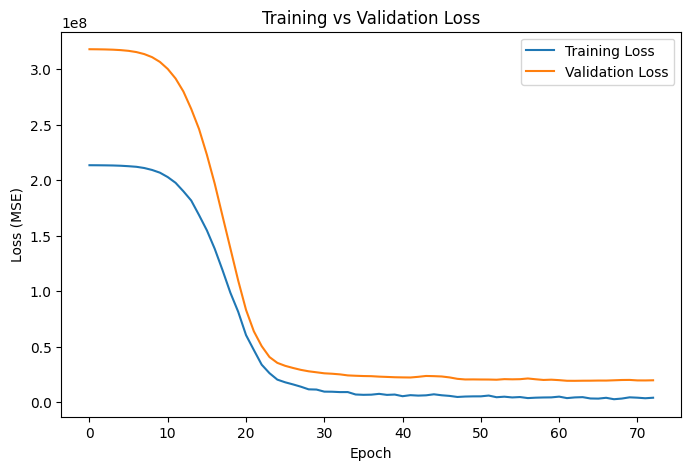

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss does not improve for 10 consecutive epochs,
# and roll back to the best weights observed
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
 
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)
 
# Visualize training vs validation loss to check for overfitting/underfitting
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Mean Absolute Error (MAE): 1944.62
Mean Squared Error (MSE): 6589354.30
Root Mean Squared Error (RMSE): 2566.97
R-squared (R2) Score: 0.9165


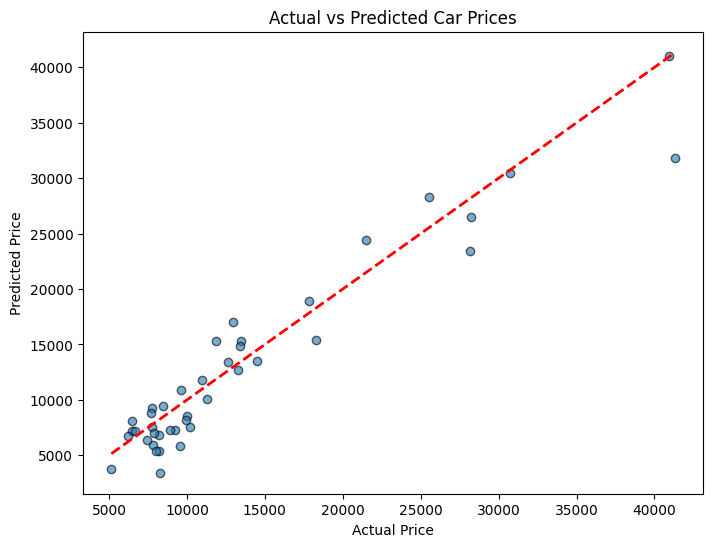

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
# Generate predictions on the test set
y_pred = model.predict(X_test_scaled).flatten()
 
# Compute regression evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
 
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")
 
# Plot actual vs predicted prices - points closer to the diagonal line
# indicate more accurate predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()


In [9]:
# Example: use a row from the test set as a stand-in for a "new" car record
# In practice, replace this with new data built through the same
# cleaning and one-hot encoding pipeline used in Steps 2-3
new_data = X_test.iloc[[0]]
new_data_scaled = scaler.transform(new_data)
 
predicted_price = model.predict(new_data_scaled)
print(f"Predicted Price for the sample car: ${predicted_price[0][0]:,.2f}")
print(f"Actual Price for reference: ${y_test.iloc[0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Price for the sample car: $30,436.29
Actual Price for reference: $30,760.00
